# Convolutional Neural Network (CNN) for Image Clasification with pyTorch

Classification of the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset

TODO: reproducibility

In [1]:
import numpy as np
from PIL import Image

from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
import utils

In [4]:
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)['cnn']

# frequently used params
width = params['img_width']
height = params['img_height']

utils.print_params(params)

img_width: 32
img_height: 32
num_workers: 2
batch_size: 32
random_state: 42
ly_conv1_out: 12
ly_conv1_kernel: 5
ly_pool_kernel: 2
ly_conv2_out: 24
ly_conv2_kernel: 5
ly_fc1_out: 120
ly_fc2_out: 84
learning_rate: 0.001
momentum: 0.9
epochs: 30
train_loop: False
model_file: data/trained/cnn_cifar10.pth


In [5]:
# reproducibility
#https://docs.pytorch.org/docs/stable/notes/randomness.html
foo = torch.manual_seed(params['random_state'])

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),  # scale to [0., 1.]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # shift to [-1.., 1.]
])

## Dataset

### Load

In [7]:
train_data = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)  # , align=False)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)  # , align=False)

c:\dev\projects\deep_dish\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
# shuffle=True for reproducibility
train_loader = torch.utils.data.DataLoader(train_data, batch_size=params['batch_size'], shuffle=True, num_workers=params['num_workers'])
test_loader = torch.utils.data.DataLoader(test_data, batch_size=params['batch_size'], shuffle=True, num_workers=params['num_workers'])

### Prepare

In [9]:
# original names
#class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#short names
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
image, label = train_data[100]

(32, 32, 3)
ship


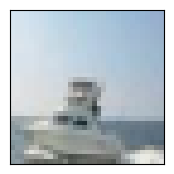

In [11]:
arr = utils.image_array(image)
print(arr.shape)

utils.imshow(arr)
print(class_names[label])

# Show in a separate window
#Image.fromarray(arr, 'RGB').show()


In [12]:
len(train_data), image.shape, image.min(), image.max(), label

(50000, torch.Size([3, 32, 32]), tensor(-0.7647), tensor(0.8980), 8)

## Model

### Build (architecture)

In [13]:
class CNNNet(nn.Module):

    def __init__(self):
        super(CNNNet, self).__init__()

        # w and h: floor((input=32 - kernel=5) / stride=1) + 1 = 28
        self.conv1 = nn.Conv2d(3, 12, 5)  # output shape (12, w, h)
        self.pool = nn.MaxPool2d(2, 2)  # output shape (12, 14, 14)
        # w and h: floor((input=14 - kernel=5) / stride=1) + 1 = 10
        self.conv2 = nn.Conv2d(12, 24, 5)  # output shape (12, 10, 10), pool again -> (24, 5, 5)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
model = CNNNet()

### Compile

In [15]:
loss_function = nn.CrossEntropyLoss()  # a.k.a. criterion

In [16]:
optimizer = optim.SGD(
    model.parameters(), lr=params['learning_rate'], momentum=params['momentum']
)

#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=params['learning_rate'],
#    momentum=params['momentum'],
#    weight_decay=1e-4,  # L2 regularization built-in
#    nesterov=True
#)

### Training loop (fit)

Or GOTO "Load"

In [17]:
if params['train_loop']:

    # for plotting
    losses = []

    for epoch in range(params['epochs']):

        model.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            X_batch, y_batch = data

            optimizer.zero_grad()

            preds = model(X_batch)

            ## y_batch.shape = [len_batch, 1] i.e., is a tensor([[1.], ... [8.]])
            ## preds.shape = [len_batch, 10]
            loss = loss_function(preds, y_batch.squeeze(-1).long())

            loss.backward()  # backpropagation
            optimizer.step()

            running_loss += loss.item()

        av_loss = running_loss / len(train_loader)  # average batch loss
        losses.append(av_loss)
        print(f"Epoch {epoch+1}/{params['epochs']}: Loss was {av_loss}")

In [18]:
if params['train_loop']:
    ax = utils.plot_train_losses(params['epochs'], losses)

### Save

In [19]:
if params['train_loop']:
    torch.save(model.state_dict(), params['model_file'])
    print(f"Saved to {params['model_file']}")

### Load

In [20]:
if not params['train_loop']:
    model = CNNNet()
    model.load_state_dict(torch.load(params['model_file']))

## Results

### Predictions

New images, not in test set, not 32 $\times$ 32

In [21]:
transform_with_resize = transforms.Compose([
    transforms.Resize((width, height)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [22]:
def load_image(image_path):
    image = Image.open(image_path)
    image = transform_with_resize(image)
#    image = image.unsqueeze(0)

    return image

In [23]:
from pathlib import Path

dir_path = Path("./data/images/cifar10_ext")
files = [p for p in dir_path.iterdir() if p.is_file()]
images = [load_image(f) for f in files]


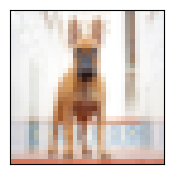

In [24]:
arr = utils.image_array(images[0])
utils.imshow(arr)

In [25]:
with torch.no_grad():
    model.eval()

    for i, image in enumerate(images):
        preds = model(image.unsqueeze(0))
        _, predicted = torch.max(preds, 1)
        print(f"Prediction {files[i]}: {class_names[predicted.item()]}")

Prediction data\images\cifar10_ext\french-bulldog-00.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-01.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-02.jpg: plane
Prediction data\images\cifar10_ext\french-bulldog-03.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-04.jpg: horse


### Evaluation (accuracy)

In [26]:
all_predicted = []
all_y_test = []
all_test_images = []  # For visualization

with torch.no_grad():
    model.eval()  # evaluation mode

    for i, data in enumerate(test_loader):
        X_batch, y_batch = data
        preds = model(X_batch)  # predicted probabilities
        _, predicted = torch.max(preds, 1)  # predicted labels

        # NOTE: concat tensor to list
        all_test_images += X_batch
        all_y_test += y_batch
        all_predicted += predicted

        if (i+1) % 50 == 0:
            print(f"{i+1}/{len(test_loader)} batches done", end="\r")

all_y_test = torch.tensor(all_y_test)  # list of tensors -> tensor
all_predicted = torch.tensor(all_predicted)  # list of tensors -> tensor
equals = (all_y_test == all_predicted)

test_acc = (equals.sum() / len(all_y_test)).item()

print(f"Test accuracy: {test_acc:.2%}")

Test accuracy: 69.26%


In [27]:
# list of mistakes indices
notequals = ~equals
notequals = np.where(notequals)[0]
len(notequals)

3074

In [28]:
all_test_images = [utils.image_array(t) for t in all_test_images]

In [29]:
real = [class_names[label_idx] for label_idx in all_y_test]
pred = [class_names[label_idx] for label_idx in all_predicted]

### Show

True label + Image:

real: horse
pred: horse


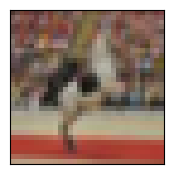

In [30]:
idx = 1
print(f"real: {real[idx]}")
print(f"pred: {pred[idx]}")
utils.imshow(all_test_images[idx])

Wrongly labeled digits in test:

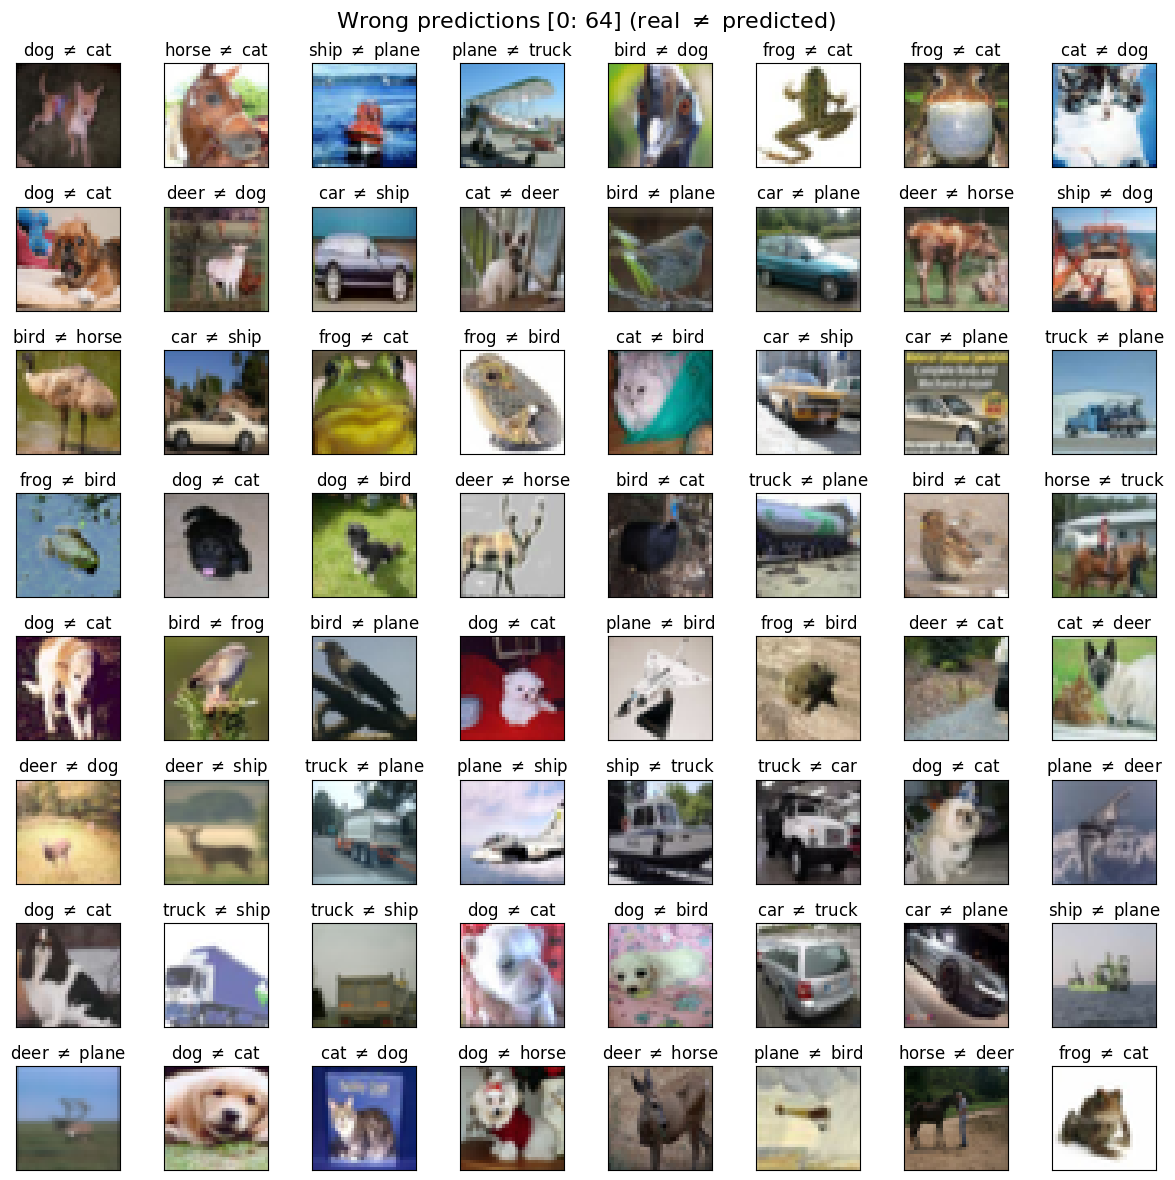

In [31]:
foo = utils.show_wrong_preds(
    all_test_images,
    real,
    pred,
    notequals,
    nrows=8,
    ncols=8,
    start_idx=0,
    img_width=width,
    img_height=height
)

Confusion matrix:

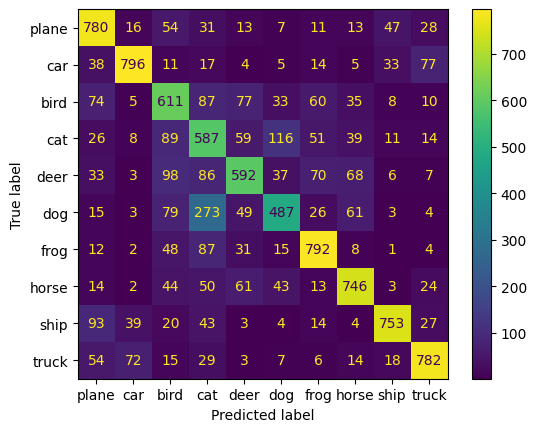

In [32]:
foo = ConfusionMatrixDisplay.from_predictions(real, pred, labels=class_names)

Specific mistakes:

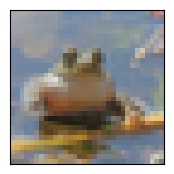

In [33]:
# frog != ship
for i in range(len(real)):
    if real[i] == 'frog' and pred[i] == 'ship':
        image = all_test_images[i]
        utils.imshow(image)